In [1]:
!pip install -q anomalib

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 72.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 81.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.2/800.2 kB 22.0 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.5.3 which is incompatibl

In [15]:
import os
DATA_ROOT = None
for root, dirs, _ in os.walk("/kaggle/input"):
    if "screw" in dirs:
        DATA_ROOT = root
        break
print("DATA_ROOT =", DATA_ROOT)
print(sorted(os.listdir(os.path.join(DATA_ROOT, "screw"))))

DATA_ROOT = /kaggle/input/datasets/ipythonx/mvtec-ad
['ground_truth', 'license.txt', 'readme.txt', 'test', 'train']


In [17]:
import os
os.environ["TQDM_DISABLE"] = "1"   # harus sebelum import anomalib

In [18]:
%pip install --force-reinstall --no-cache-dir numpy==2.0.2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 290.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
imagecodecs 2026.8.16 requires numpy>=2.1, but you have numpy 2.0.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator

In [19]:
from anomalib.data import MVTecAD
from anomalib.models import Patchcore
from anomalib.models import Padim
from anomalib.engine import Engine

dm = MVTecAD(root=DATA_ROOT, category="screw")
model = Patchcore()
model_padim = Padim()
engine = Engine(
    accelerator="gpu",
    devices=1,
    default_root_dir="/kaggle/working/results",
    enable_progress_bar=False,
)
engine_padim = Engine(
    accelerator="gpu",
    devices=1,
    default_root_dir="/kaggle/working/results",
    enable_progress_bar=False,
)

In [20]:
engine_padim.fit(model=model_padim, datamodule=dm)
hasil_padim = engine_padim.test(model=model_padim, datamodule=dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor  │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator     │      0 │ train │     0 │
│ 3 │ model          │ PadimModel    │  2.8 M │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11.131                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might 

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │    0.8177905678749084     │
│       image_F1Score       │    0.8735632300376892     │
│        pixel_AUROC        │    0.9759213924407959     │
│       pixel_F1Score       │    0.2207476794719696     │
└───────────────────────────┴───────────────────────────┘

In [21]:
engine.fit(model=model, datamodule=dm)
engine.test(model=model, datamodule=dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │ 24.9 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 24.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.9 M                                                                                               
Total estimated model params size (MB): 99.450                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 174                                                                                          
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:538: Found 174 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.
`Trainer.fit` stopped: `max_epochs=1` reached.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │    0.9622873067855835     │
│       image_F1Score       │    0.9504132270812988     │
│        pixel_AUROC        │    0.9883605241775513     │
│       pixel_F1Score       │    0.3722985088825226     │
└───────────────────────────┴───────────────────────────┘

[{'image_AUROC': 0.9622873067855835,
  'image_F1Score': 0.9504132270812988,
  'pixel_AUROC': 0.9883605241775513,
  'pixel_F1Score': 0.3722985088825226}]

166 gambar
/kaggle/working/results/Patchcore/MVTecAD/bottle/latest/images/broken_large/000.png


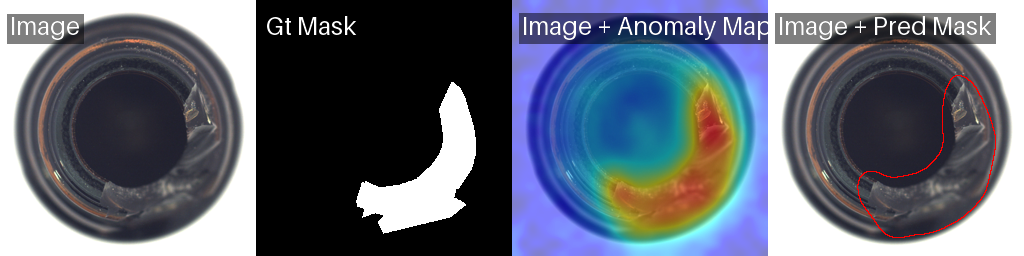

/kaggle/working/results/Patchcore/MVTecAD/bottle/latest/images/broken_large/001.png


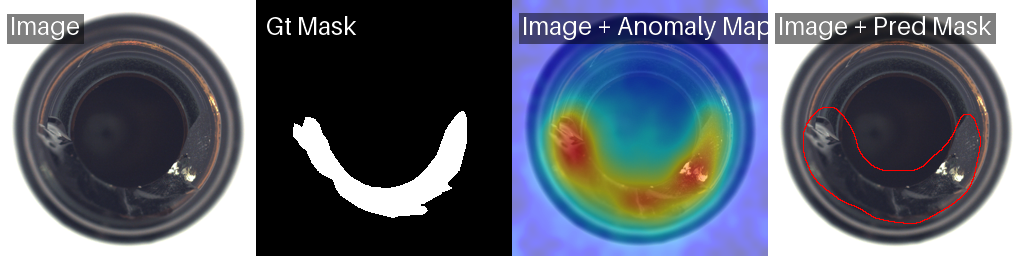

/kaggle/working/results/Patchcore/MVTecAD/bottle/latest/images/broken_large/002.png


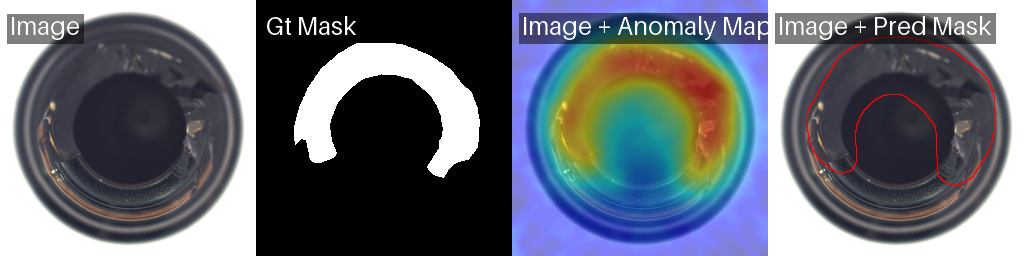

/kaggle/working/results/Patchcore/MVTecAD/bottle/latest/images/broken_large/003.png


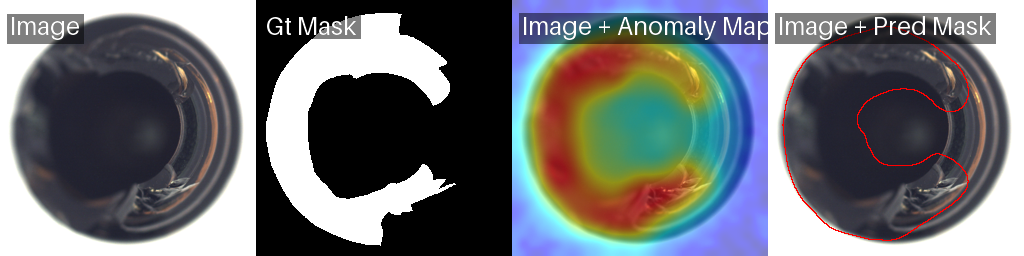

In [29]:
import glob
from IPython.display import Image, display
imgs = sorted(glob.glob("/kaggle/working/results/Patchcore/MVTecAD/bottle/**/*.png", recursive=True))
print(len(imgs), "gambar")
for p in imgs[:4]:
    print(p); display(Image(p, width=700))

249 gambar
/kaggle/working/results/Padim/MVTecAD/bottle/latest/images/broken_large/000.png


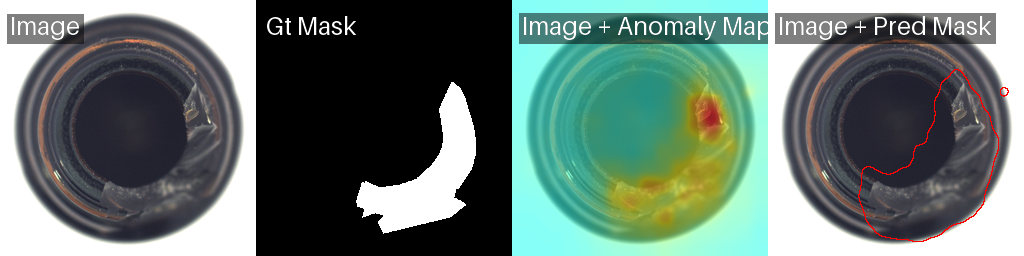

/kaggle/working/results/Padim/MVTecAD/bottle/latest/images/broken_large/001.png


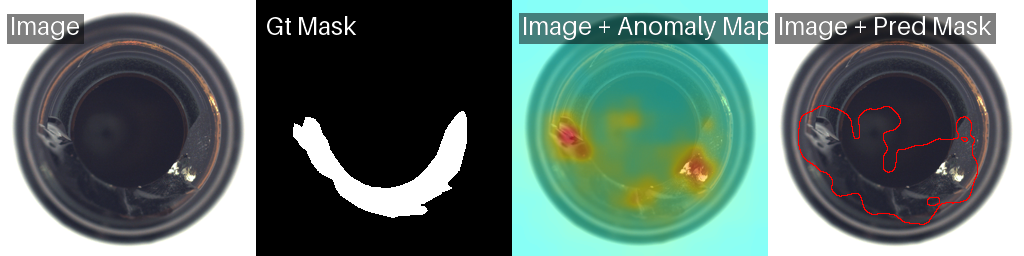

/kaggle/working/results/Padim/MVTecAD/bottle/latest/images/broken_large/002.png


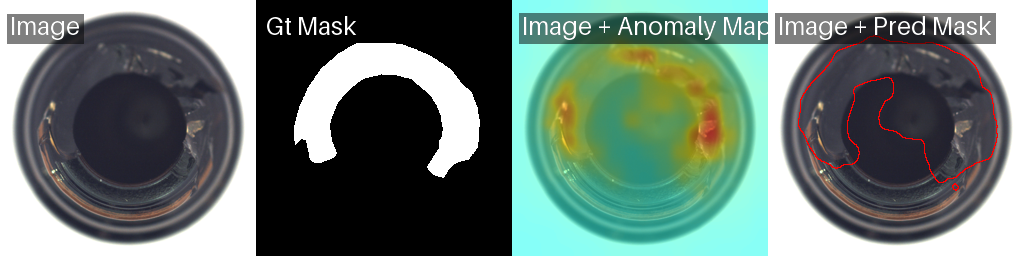

/kaggle/working/results/Padim/MVTecAD/bottle/latest/images/broken_large/003.png


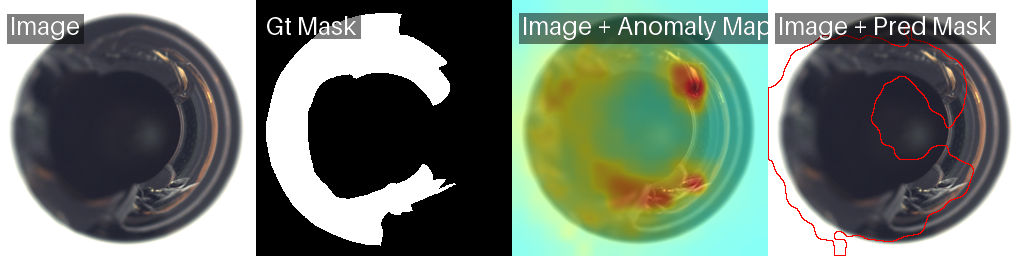

In [28]:
import glob
from IPython.display import Image, display
imgs = sorted(glob.glob("/kaggle/working/results/Padim/MVTecAD/bottle/**/*.png", recursive=True))
print(len(imgs), "gambar")
for p in imgs[:4]:
    print(p); display(Image(p, width=700))

In [23]:
import pandas as pd

hasil_patchcore = engine.test(model=model, datamodule=dm)

tabel = pd.DataFrame([
    {"metode": "PatchCore", "kategori": "screw", **hasil_patchcore[0]},
    {"metode": "PaDiM",     "kategori": "screw", **hasil_padim[0]},
]).round(4)
tabel

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │    0.9622873067855835     │
│       image_F1Score       │    0.9504132270812988     │
│        pixel_AUROC        │    0.9883604645729065     │
│       pixel_F1Score       │    0.3722985088825226     │
└───────────────────────────┴───────────────────────────┘

,metode,kategori,image_AUROC,image_F1Score,pixel_AUROC,pixel_F1Score
0,PatchCore,screw,0.9623,0.9504,0.9884,0.3723
1,PaDiM,screw,0.8178,0.8736,0.9759,0.2207
